# Third-edition lever sweep

The report defines its scenarios as combinations of five levers and publishes three of them
(S0, S1, S2). This notebook runs the rest of the grid: every combination of traffic growth,
aircraft technology, operations and SAF deployment.

    3 traffic x 4 technology x 3 operations x 3 SAF = 108 runs

Market-based measures are not swept. They are computed as the residual needed to reach the
target, so they follow from the other four levers rather than varying independently.

Processes are built on the fly by `sweep.py` rather than from 108 committed configuration
files, and each one is discarded as soon as it has been reduced to the series worth keeping,
so peak memory is a single process.

**A note on SAF resolution.** F2 and F3 are published as quantities *per pathway*, so they map
onto the eleven-carrier energy files of the full edition. F1 publishes only a total volume with
no pathway breakdown, so it is modelled as a single generic SAF carrier, reusing the light
edition's S0 energy file rather than inventing a pathway split. Pathway-level outputs are
therefore undefined for the F1 arm, and comparisons across the SAF axis stay on totals.

In [1]:
%matplotlib widget
import json
import time

import pandas as pd

from aeromaps import assemble_processes

import sweep

## Benchmark before committing to 108 runs

`compute_all` is sequential, so the grid costs 108 times one run. Time one cell first.

In [2]:
start = time.perf_counter()
reference = sweep.build_process(*sweep.PUBLISHED_CELLS["S1"])
reference.compute()
elapsed = time.perf_counter() - start

print(f"one cell: {elapsed:.1f} s  ->  108 cells ~ {elapsed * 108 / 60:.0f} min")

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: residual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: manual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


one cell: 3.9 s  ->  108 cells ~ 7 min

## The grid reproduces the published scenario

S1 is the central/T3/O3/F2 cell of this grid, so it must come back identical to the committed
scenario output. If it does not, the lever mapping is wrong and nothing below is meaningful.

In [3]:
committed = json.loads((sweep.ATAG / "3rd_edition_full" / "data_outputs" / "s1.json").read_text())[
    "climate_outputs"
]
computed = reference.data["climate_outputs"]
years = reference.data["years"]["climate_full_years"]

worst = 0.0
for column, values in committed.items():
    if column not in computed:
        continue
    published = pd.Series(values, index=years)
    scale = max(published.abs().max(), 1e-12)
    worst = max(worst, float((computed.loc[years, column] - published).abs().max() / scale))

print(f"worst relative difference against committed s1.json: {worst:.2e}")
# Tolerance is 1e-3 rather than machine precision. The committed outputs were
# generated on Linux; on other platforms the aerosol forcing chain (soot_erf ->
# aerosol_erf -> the temperature integral) differs at the 1e-5 level, while ~77%
# of series still match bit-for-bit. A real model change moves whole families of
# outputs well past this bound, so the guard still does its job.
assert worst < 1e-3, "the central/T3/O3/F2 cell does not reproduce the published S1"

worst relative difference against committed s1.json: 0.00e+00

## Run the sweep

Results are persisted as one tidy frame of annual series, small enough to commit, so the
document can read them back without re-running anything.

In [4]:
tidy = sweep.run_sweep()
path = sweep.write_results(tidy)
print(f"{len(tidy):,} rows written to {path.name}")

[  1/108] low     T1 O1 F1

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: residual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: manual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


102,816 rows written to sweep_results.csv.gz

In [5]:
summary = sweep.summarise(tidy, year=2050)
summary[
    [
        "traffic",
        "technology",
        "operations",
        "saf",
        "co2_emissions",
        "carbon_offset",
        "temperature_increase_from_aviation",
    ]
].sort_values("co2_emissions").head(12)

variable,traffic,technology,operations,saf,co2_emissions,carbon_offset,temperature_increase_from_aviation
97,low,T3,O3,F2,207.7,207.7,0.0716553
106,low,T4,O3,F2,212.026,212.026,0.0677727
94,low,T3,O2,F2,214.329,214.329,0.0722526
88,low,T2,O3,F2,216.939,216.939,0.0721968
103,low,T4,O2,F2,218.793,218.793,0.0682929
98,low,T3,O3,F3,219.635,219.635,0.072279
91,low,T3,O1,F2,220.957,220.957,0.0728774
107,low,T4,O3,F3,222.251,222.251,0.0682456
85,low,T2,O2,F2,223.863,223.863,0.0728341
100,low,T4,O1,F2,225.559,225.559,0.0688298


## Where the published scenarios sit in the grid

The spread over the whole grid is the quantity the report does not publish: how much of the
2050 outcome is settled by the lever combination rather than by the two illustrative choices.

In [6]:
residual = summary.set_index(["traffic", "technology", "operations", "saf"])["co2_emissions"]

print("2050 residual CO2 across the grid [Mt]:")
print(f"  min    {residual.min():8.0f}   ({residual.idxmin()})")
print(f"  median {residual.median():8.0f}")
print(f"  max    {residual.max():8.0f}   ({residual.idxmax()})")
for name, cell in sweep.PUBLISHED_CELLS.items():
    print(f"  {name}     {residual.loc[cell]:8.0f}   ({cell})")

2050 residual CO2 across the grid [Mt]:

  min         208   (('low', 'T3', 'O3', 'F2'))

  median      731

  max        2164   (('high', 'T1', 'O1', 'F1'))

  S1          424   (('central', 'T3', 'O3', 'F2'))

  S2          361   (('central', 'T4', 'O3', 'F3'))

## The whole grid at once

Every one of the 108 combinations, drawn as a single translucent line, across four metrics: CO₂
emissions, final energy, energy intensity and carbon intensity. Individual runs rather than a
min/max envelope, because the grid is not one ordered family — it is four levers crossed, and the
density of the bundle is the point.

The published S1 and S2 are overlaid in black, so the two reported cases can be located inside the
spread they belong to.

The series start at the last observed year rather than 2019: the COVID collapse drives RPK down
without a matching drop in energy, so 2020 reads about 2.3 MJ/RPK against a 1.4 trend, and that
spike compresses both intensity panels into illegibility.

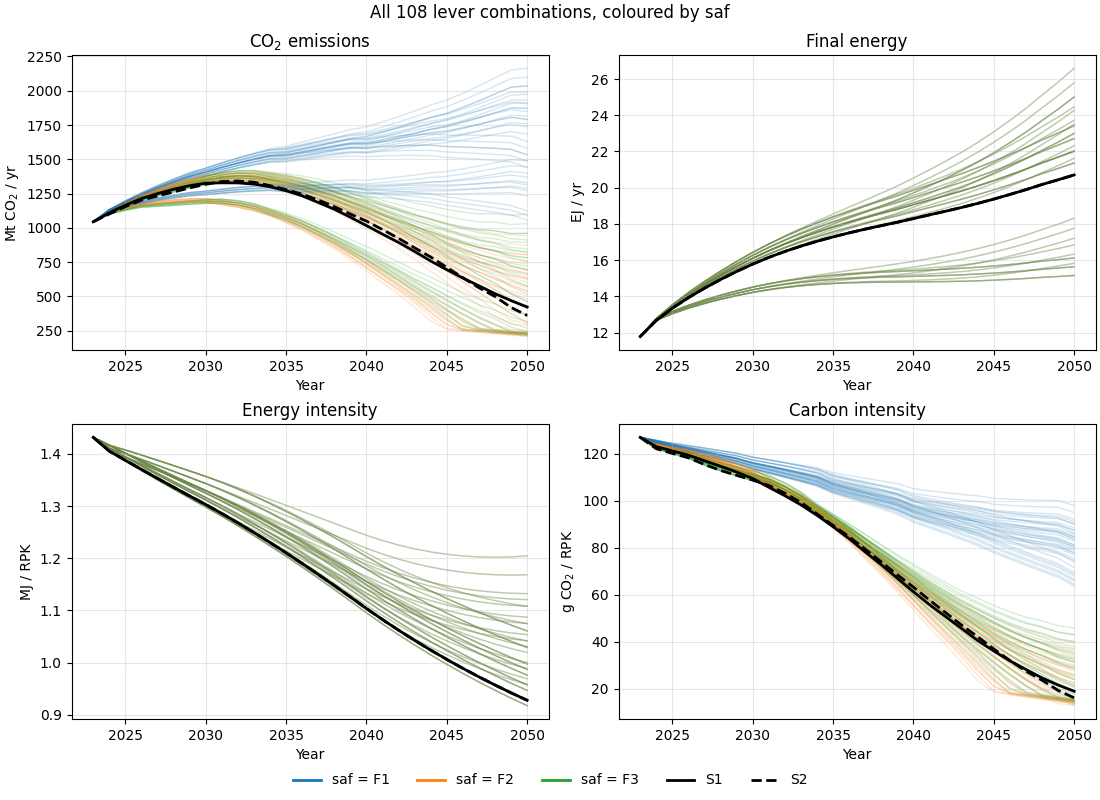

In [7]:
figure, axes = sweep.plot_grid(color_by="saf")

Colouring by SAF separates the two carbon panels cleanly and does nothing at all to the two energy
panels — which is exactly right, and worth seeing: substituting the fuel changes what a joule
emits, not how many joules are burned.

Colouring the same figure by traffic shows the complement.

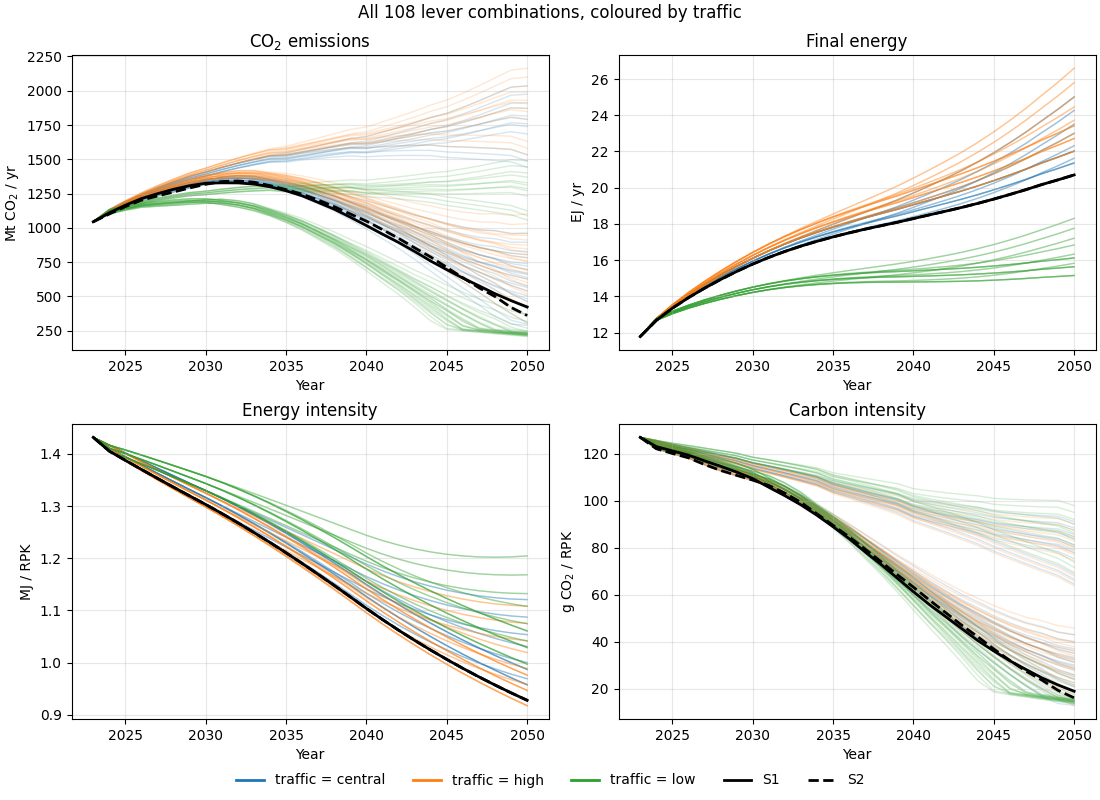

In [8]:
figure, axes = sweep.plot_grid(color_by="traffic")

## Technology against operations, at central traffic

Grouped with the standard comparison plot: one envelope per technology variant, spanning the
three operations levels.

In [9]:
processes = {}
groups = {}
for technology in sweep.TECHNOLOGY_LEVELS:
    groups[technology] = []
    for operations in sweep.OPERATIONS_LEVELS:
        name = f"{technology} - {operations}"
        process = sweep.build_process("central", technology, operations, "F2")
        process.compute()
        processes[name] = process
        groups[technology].append(name)

assembly = assemble_processes(processes)

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: electrolysis_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: residual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: manual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\plots\multi_scenario\emissions.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax.legend(loc='best')


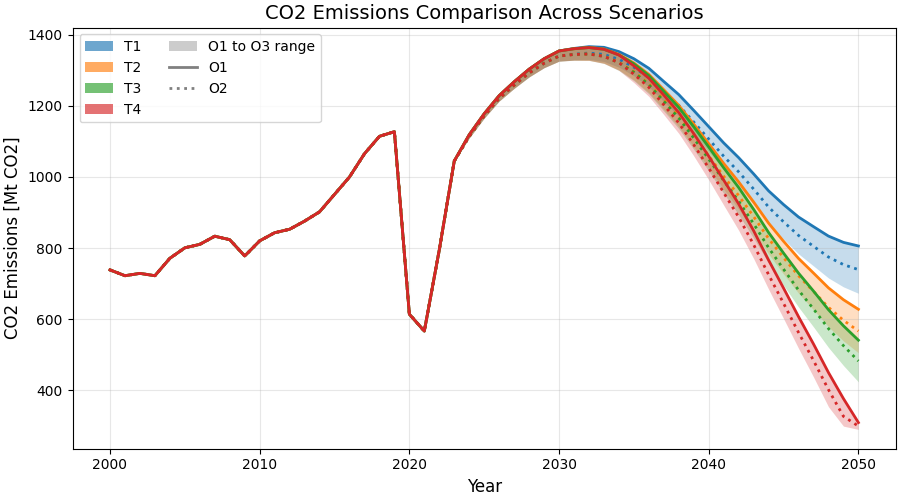

In [10]:
assembly.plot("co2_emissions_comparison", scenario_groups=groups, group_display="envelope")

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\plots\multi_scenario\climate.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax.legend(loc="best")


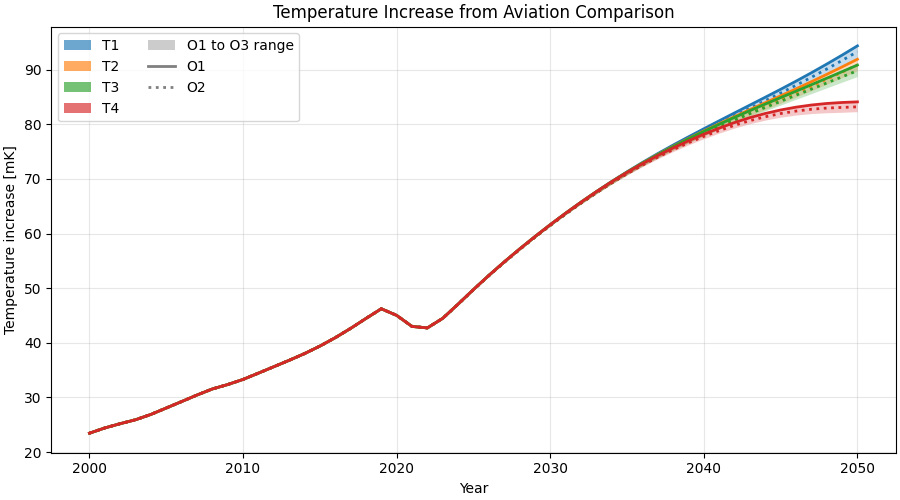

In [11]:
assembly.plot("temperature_increase_comparison", scenario_groups=groups, group_display="envelope")

## Per-mechanism climate decomposition

The published scenarios reach net zero CO2 while their warming contribution stays dominated by
non-CO2 terms, which is visible only once the mechanisms are separated.

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - short_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - medium_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\core\gemseo.py:271: UserWarning: [LoadFactorMarket - long_range] The quadratic load-factor model was calibrated for a horizon of 31 years (end_year=2050, last_historical_year=2019). The current scenario has a horizon of 27 years (end_year=2050, last_historical_year=2023). The arrival-slope constraint (≈ 0 %/yr at end_year) is applied unchanged. For a model without this limitation, use LoadFactorMarketSimpleInterpolation (set global.load_factor.model: simple_interpolation in markets.yaml).
  return self.model.compute(input_data)


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


...

C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: electrolysis_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\yaml_interpolator.py:189: UserWarning: 
[Interpolation Model: battery_electric_mean_mfsp_without_resource Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: residual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: manual_carbon_offset Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\PycharmProjects\AeroMAPS\aeromaps\models\base.py:294: UserWarning: 
[Interpolation Model: exogenous_carbon_price_trajectory Warning]
The first reference year (2020) differs from the prospection start year (2024).
Interpolation will begin at the first reference year.
  warnings.warn(


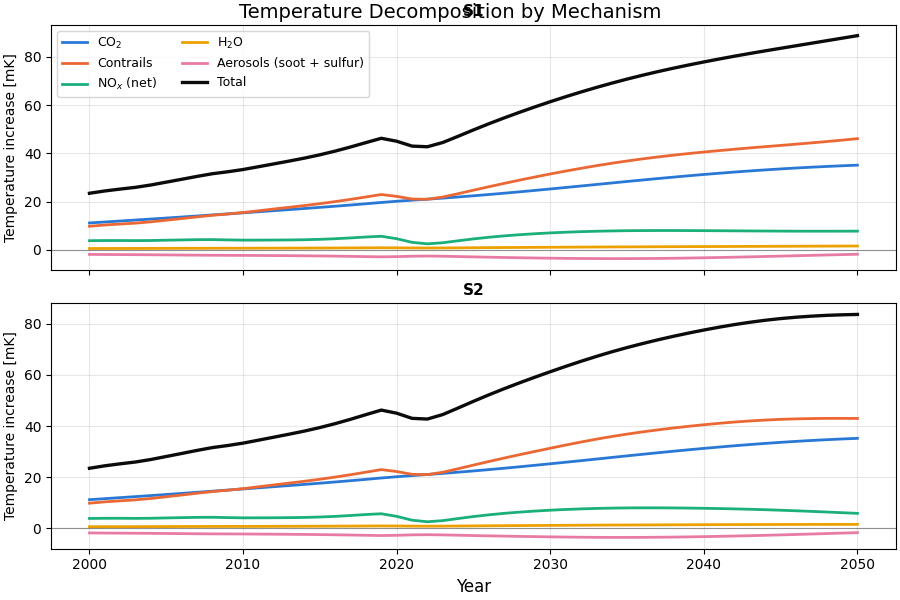

In [12]:
published = assemble_processes(
    {name: sweep.build_process(*cell) for name, cell in sweep.PUBLISHED_CELLS.items()}
)
published.compute_all()
published.plot("temperature_decomposition_comparison")